In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/kaggle/input/e-commerce-customer-churn/data_ecommerce_customer_churn.csv")
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [2]:
df.shape

(3941, 11)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [4]:
df.describe()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3747.000000,3772.000000,3941.000000,3941.000000,3941.000000,3941.000000,3728.000000,3941.000000,3941.000000
mean,10.081398,15.650583,3.679269,3.088302,4.237757,0.282416,4.531652,176.707419,0.171023
std,8.498864,8.452301,1.013938,1.381832,2.626699,0.450232,3.667648,48.791784,0.376576
min,0.000000,5.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,9.000000,3.000000,2.000000,2.000000,0.000000,2.000000,145.700000,0.000000
50%,9.000000,14.000000,4.000000,3.000000,3.000000,0.000000,3.000000,163.340000,0.000000
75%,16.000000,21.000000,4.000000,4.000000,6.000000,1.000000,7.000000,195.250000,0.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,1.000000,46.000000,324.990000,1.000000


In [5]:
df.columns

Index(['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
       'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus',
       'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount',
       'Churn'],
      dtype='object')

In [6]:
df.dtypes

Tenure                      float64
WarehouseToHome             float64
NumberOfDeviceRegistered      int64
PreferedOrderCat             object
SatisfactionScore             int64
MaritalStatus                object
NumberOfAddress               int64
Complain                      int64
DaySinceLastOrder           float64
CashbackAmount              float64
Churn                         int64
dtype: object

In [7]:
df["Churn"].value_counts()

Churn
0    3267
1     674
Name: count, dtype: int64

In [8]:
df.isnull().sum()

Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

In [9]:
df["Tenure"].fillna(df["Tenure"].median(), inplace=True)
df["WarehouseToHome"].fillna(df["WarehouseToHome"].median(), inplace=True)
df["DaySinceLastOrder"].fillna(df["DaySinceLastOrder"].median(), inplace=True)

/tmp/ipykernel_55/3448554972.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Tenure"].fillna(df["Tenure"].median(), inplace=True)
/tmp/ipykernel_55/3448554972.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [10]:
df.isnull().sum()

Tenure                      0
WarehouseToHome             0
NumberOfDeviceRegistered    0
PreferedOrderCat            0
SatisfactionScore           0
MaritalStatus               0
NumberOfAddress             0
Complain                    0
DaySinceLastOrder           0
CashbackAmount              0
Churn                       0
dtype: int64

In [11]:
df = pd.get_dummies(
    df,
    columns=["PreferedOrderCat", "MaritalStatus"],
    drop_first=True,
    dtype = 'int'
)

In [12]:
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,15.0,29.0,4,3,2,0,7.0,143.32,0,0,1,0,0,0,0,1
1,7.0,25.0,4,1,2,0,7.0,129.29,0,0,0,1,0,0,1,0
2,27.0,13.0,3,1,5,0,7.0,168.54,0,0,1,0,0,0,1,0
3,20.0,25.0,4,3,7,0,3.0,230.27,0,0,0,0,0,0,0,0
4,30.0,15.0,4,4,8,0,8.0,322.17,0,0,0,0,0,1,0,1


In [13]:
df.dtypes

Tenure                                 float64
WarehouseToHome                        float64
NumberOfDeviceRegistered                 int64
SatisfactionScore                        int64
NumberOfAddress                          int64
Complain                                 int64
DaySinceLastOrder                      float64
CashbackAmount                         float64
Churn                                    int64
PreferedOrderCat_Grocery                 int64
PreferedOrderCat_Laptop & Accessory      int64
PreferedOrderCat_Mobile                  int64
PreferedOrderCat_Mobile Phone            int64
PreferedOrderCat_Others                  int64
MaritalStatus_Married                    int64
MaritalStatus_Single                     int64
dtype: object

In [14]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)
X_train_res = X_train_resampled
y_train_res = y_train_resampled

In [17]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight="balanced",
    random_state=42
)

lgbm.fit(X_train_res, y_train_res)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2613, number of negative: 2613
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1061
[LightGBM] [Info] Number of data points in the train set: 5226, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(class_weight='balanced', colsample_bytree=0.9,
               learning_rate=0.03, n_estimators=800, random_state=42,
               subsample=0.9)

In [18]:
from sklearn.metrics import classification_report, roc_auc_score

def evaluate(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = (y_prob >= 0.4).astype(int)

    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [19]:
evaluate(lgbm, X_test, y_test)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       654
           1       0.80      0.82      0.81       135

    accuracy                           0.93       789
   macro avg       0.88      0.89      0.89       789
weighted avg       0.93      0.93      0.93       789

ROC-AUC: 0.955770755464945


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


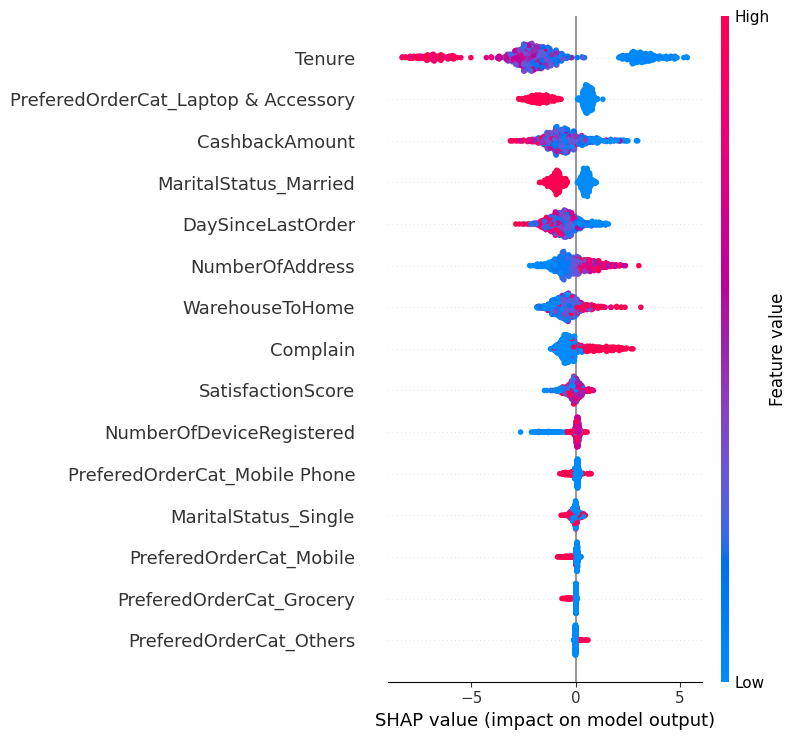

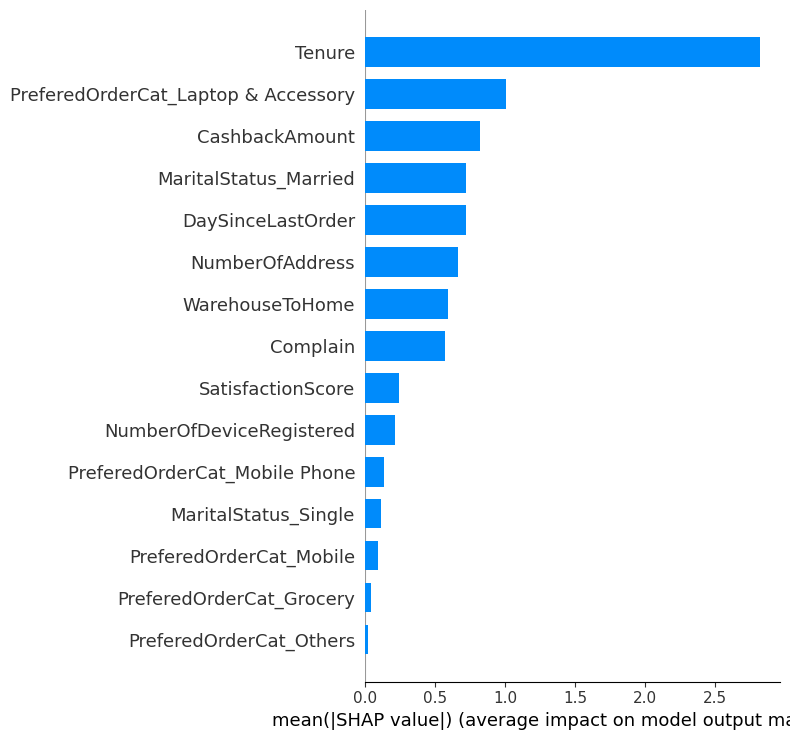

In [20]:
import shap
import numpy as np

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [34]:
import pandas as pd

sample_customer = pd.DataFrame([{
    "Tenure": 8,
    "WarehouseToHome": 15,
    "NumberOfDeviceRegistered": 4,
    "SatisfactionScore": 2,
    "NumberOfAddress": 3,
    "Complain": 1,
    "DaySinceLastOrder": 10,
    "CashbackAmount": 160,

    "PreferedOrderCat_Grocery": 0,
    "PreferedOrderCat_Laptop & Accessory": 1,
    "PreferedOrderCat_Mobile": 0,
    "PreferedOrderCat_Mobile Phone": 0,
    "PreferedOrderCat_Others": 0,

    "MaritalStatus_Married": 1,
    "MaritalStatus_Single": 0
}])


In [35]:
sample_customer = sample_customer[X_train.columns]


In [36]:
prob = lgbm.predict_proba(sample_customer)[0][1]
pred = int(prob >= 0.5)

print("Churn Probability:", round(prob, 3))
print("Prediction:", "Churn" if pred == 1 else "No Churn")


Churn Probability: 0.0
Prediction: No Churn


In [37]:
test_customers = pd.DataFrame([
    {
        "Tenure": 2,
        "WarehouseToHome": 30,
        "NumberOfDeviceRegistered": 5,
        "SatisfactionScore": 1,
        "NumberOfAddress": 5,
        "Complain": 1,
        "DaySinceLastOrder": 25,
        "CashbackAmount": 90,

        "PreferedOrderCat_Grocery": 0,
        "PreferedOrderCat_Laptop & Accessory": 0,
        "PreferedOrderCat_Mobile": 1,
        "PreferedOrderCat_Mobile Phone": 0,
        "PreferedOrderCat_Others": 0,

        "MaritalStatus_Married": 0,
        "MaritalStatus_Single": 1
    },

    {
        "Tenure": 20,
        "WarehouseToHome": 5,
        "NumberOfDeviceRegistered": 2,
        "SatisfactionScore": 5,
        "NumberOfAddress": 1,
        "Complain": 0,
        "DaySinceLastOrder": 2,
        "CashbackAmount": 300,

        "PreferedOrderCat_Grocery": 1,
        "PreferedOrderCat_Laptop & Accessory": 0,
        "PreferedOrderCat_Mobile": 0,
        "PreferedOrderCat_Mobile Phone": 0,
        "PreferedOrderCat_Others": 0,

        "MaritalStatus_Married": 1,
        "MaritalStatus_Single": 0
    }
])

test_customers = test_customers[X_train.columns]


In [25]:
test_customers["churn_probability"] = lgbm.predict_proba(test_customers)[:,1]
test_customers["prediction"] = (test_customers["churn_probability"] >= 0.5).astype(int)

test_customers


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,churn_probability,prediction
0,2,30,5,1,5,1,25,90,0,0,1,0,0,0,1,0.334254,0
1,20,5,2,5,1,0,2,300,1,0,0,0,0,1,0,0.000032,0


In [26]:
import joblib

joblib.dump(lgbm, "ecommerce_lightgbm_model.pkl")


['ecommerce_lightgbm_model.pkl']

In [27]:
joblib.dump(X_train.columns.tolist(),
            "ecommerce_features.pkl")


['ecommerce_features.pkl']

In [38]:
import pandas as pd

sample_customer = pd.DataFrame([{
    "Tenure": 5,
    "WarehouseToHome": 30,
    "NumberOfDeviceRegistered": 5,
    "SatisfactionScore": 1,
    "NumberOfAddress": 4,
    "Complain": 1,
    "DaySinceLastOrder": 25,
    "CashbackAmount": 90,

    "PreferedOrderCat_Grocery": 0,
    "PreferedOrderCat_Laptop & Accessory": 0,
    "PreferedOrderCat_Mobile": 1,
    "PreferedOrderCat_Mobile Phone": 0,
    "PreferedOrderCat_Others": 0,
    

    "MaritalStatus_Married": 0,
    "MaritalStatus_Single": 1
}])


In [39]:
sample_customer = sample_customer[X_train.columns]


In [40]:
prob = lgbm.predict_proba(sample_customer)[0][1]
prediction = int(prob >= 0.5)

print("Churn Probability:", round(prob, 3))
print("Prediction:", "CHURN" if prediction == 1 else "NO CHURN")


Churn Probability: 0.51
Prediction: CHURN


In [31]:
test_customers = pd.DataFrame([
    {
        "Tenure": 3,
        "WarehouseToHome": 40,
        "NumberOfDeviceRegistered": 5,
        "SatisfactionScore": 1,
        "NumberOfAddress": 5,
        "Complain": 1,
        "DaySinceLastOrder": 30,
        "CashbackAmount": 80,

        "PreferedOrderCat_Grocery": 0,
        "PreferedOrderCat_Laptop & Accessory": 0,
        "PreferedOrderCat_Mobile": 1,
        "PreferedOrderCat_Mobile Phone": 0,
        "PreferedOrderCat_Others": 0,

        "MaritalStatus_Married": 0,
        "MaritalStatus_Single": 1
    },

    {
        "Tenure": 25,
        "WarehouseToHome": 5,
        "NumberOfDeviceRegistered": 2,
        "SatisfactionScore": 5,
        "NumberOfAddress": 1,
        "Complain": 0,
        "DaySinceLastOrder": 2,
        "CashbackAmount": 300,

        "PreferedOrderCat_Grocery": 1,
        "PreferedOrderCat_Laptop & Accessory": 0,
        "PreferedOrderCat_Mobile": 0,
        "PreferedOrderCat_Mobile Phone": 0,
        "PreferedOrderCat_Others": 0,

        "MaritalStatus_Married": 1,
        "MaritalStatus_Single": 0
    }
])

test_customers = test_customers[X_train.columns]


In [32]:
test_customers["Churn_Probability"] = lgbm.predict_proba(test_customers)[:,1]
test_customers["Prediction"] = (
    test_customers["Churn_Probability"] >= 0.5
).astype(int)

test_customers


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,Churn_Probability,Prediction
0,3,40,5,1,5,1,30,80,0,0,1,0,0,0,1,0.656403,1
1,25,5,2,5,1,0,2,300,1,0,0,0,0,1,0,0.000004,0


In [41]:
sample = pd.DataFrame([{
    "Tenure":2,
    "WarehouseToHome":30,
    "NumberOfDeviceRegistered":1,
    "SatisfactionScore":1,
    "NumberOfAddress":1,
    "Complain":1,
    "DaySinceLastOrder":25,
    "CashbackAmount":50,
    "PreferedOrderCat":"Laptop & Accessory",
    "MaritalStatus":"Single"
}])

sample = pd.get_dummies(sample,
                        columns=["PreferedOrderCat","MaritalStatus"],
                        drop_first=True)

for col in X_train.columns:
    if col not in sample.columns:
        sample[col] = 0

sample = sample[X_train.columns]

print(lgbm.predict_proba(sample))



[[0.74221691 0.25778309]]
